In [ ]:
import datetime
from packaging import version
from collections import Counter
import numpy as np
import pandas as pd
import time
import os
import re
import string

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds
from tensorflow.keras import layers
import tensorflow.keras.backend as k

%matplotlib inline
np.set_printoptions(precision=3, suppress=True)

print("This notebook requires TensorFlow 2.0 or above")
print("TensorFlow version:", tf.__version__)
assert version.parse(tf.__version__).release[0] >= 2



This notebook requires TensorFlow 2.0 or above
TensorFlow version: 2.19.0


In [ ]:
ri = tfds.core.ReadInstruction('train') + tfds.core.ReadInstruction('test')

dataset_all, info = tfds.load(
    'ag_news_subset',
    with_info=True,
    split=ri,
    as_supervised=True
)

text_only_dataset_all = dataset_all.map(lambda x, y: x)

categories = dict(enumerate(info.features["label"].names))
print("Dictionary:", categories)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.1AWDRT_1.0.0/ag_news_subset-train.tfrecord*...: …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.1AWDRT_1.0.0/ag_news_subset-test.tfrecord*...:  …

Dataset ag_news_subset downloaded and prepared to /root/tensorflow_datasets/ag_news_subset/1.0.0. Subsequent calls will reuse this data.
Dictionary: {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}


In [ ]:
train_categories = [
    categories[label]
    for label in dataset_all.map(lambda text, label: label).as_numpy_iterator()
]

Counter(train_categories).most_common()


[('Sci/Tech', 31900), ('Sports', 31900), ('Business', 31900), ('World', 31900)]

In [ ]:
train_ds, info = tfds.load(
    "ag_news_subset",
    split="train",
    with_info=True,
    as_supervised=True
)

test_ds = tfds.load(
    "ag_news_subset",
    split="test",
    as_supervised=True
)

print("Train examples:", info.splits["train"].num_examples)
print("Test examples:", info.splits["test"].num_examples)

Train examples: 120000
Test examples: 7600


In [ ]:
nltk.download('stopwords', quiet=True)
STOPWORDS = stopwords.words("english")

def custom_stopwords(input_text):
    lowercase = tf.strings.lower(input_text)
    stripped_punct = tf.strings.regex_replace(
        lowercase,
        '[%s]' % re.escape(string.punctuation),
        ''
    )
    return tf.strings.regex_replace(
        stripped_punct,
        r'\b(' + r'|'.join(STOPWORDS) + r')\b\s*',
        ""
    )


In [ ]:
max_tokens = None

text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    standardize=custom_stopwords
)

text_vectorization.adapt(text_only_dataset_all)

vocab = np.array(text_vectorization.get_vocabulary())
print("Vocabulary Size:", len(vocab))
print(vocab[:50])


Vocabulary Size: 95827
['' '[UNK]' '39s' 'said' 'new' 'us' 'reuters' 'ap' 'two' 'first' 'monday'
 'wednesday' 'tuesday' 'thursday' 'company' 'friday' 'inc' 'one' 'world'
 'yesterday' 'last' 'york' 'year' 'president' 'million' 'oil' 'corp'
 'united' 'would' 'sunday' 'years' 'week' 'people' 'today' 'three'
 'government' 'could' 'quot' 'group' 'time' 'percent' 'game' 'saturday'
 'software' 'night' 'next' 'prices' 'iraq' 'security' 'announced']


Min: 2
Median: 20.0
Max: 95


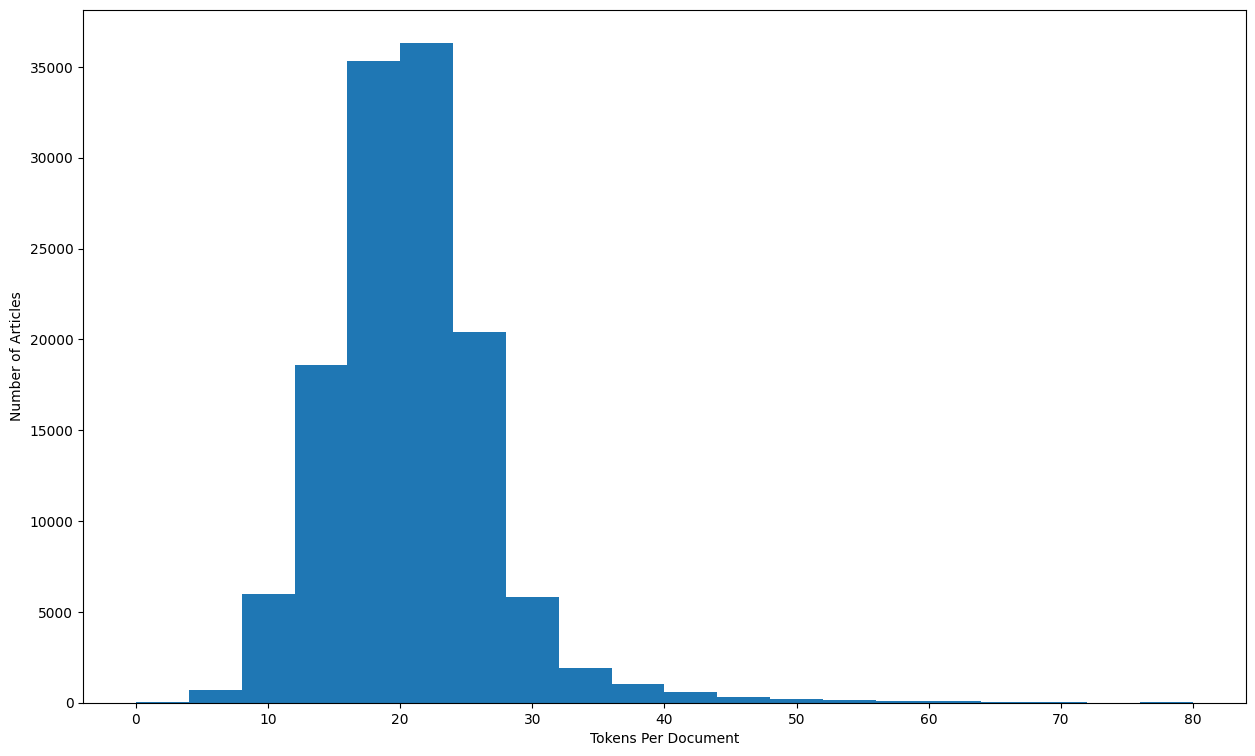

In [ ]:
doc_sizes = []

for example, _ in dataset_all.as_numpy_iterator():
    enc_example = text_vectorization(example)
    doc_sizes.append(len(enc_example))

print("Min:", min(doc_sizes))
print("Median:", np.median(doc_sizes))
print("Max:", max(doc_sizes))

plt.figure(figsize=(15,9))
plt.hist(doc_sizes, bins=20, range=(0,80))
plt.xlabel("Tokens Per Document")
plt.ylabel("Number of Articles")
plt.show()


# Experiment A (a): Three vocab sizes

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers
import nltk
from nltk.corpus import stopwords
import re
import string


In [ ]:
ri = tfds.core.ReadInstruction('train') + tfds.core.ReadInstruction('test')

dataset_all, info = tfds.load(
    'ag_news_subset',
    with_info=True,
    split=ri,
    as_supervised=True
)

text_only_dataset_all = dataset_all.map(lambda x, y: x)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.EMG5Q5_1.0.0/ag_news_subset-train.tfrecord*...: …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.EMG5Q5_1.0.0/ag_news_subset-test.tfrecord*...:  …

Dataset ag_news_subset downloaded and prepared to /root/tensorflow_datasets/ag_news_subset/1.0.0. Subsequent calls will reuse this data.


In [ ]:
nltk.download('stopwords', quiet=True)
STOPWORDS = stopwords.words("english")

def custom_stopwords(input_text):
    lowercase = tf.strings.lower(input_text)
    stripped_punct = tf.strings.regex_replace(
        lowercase,
        '[%s]' % re.escape(string.punctuation),
        ''
    )
    return tf.strings.regex_replace(
        stripped_punct,
        r'\b(' + r'|'.join(STOPWORDS) + r')\b\s*',
        ""
    )


In [ ]:
level = 1000

print(f"\n Vocabulary Size = {level} ")

tv_exp = layers.TextVectorization(
    max_tokens=level,
    output_mode="int",
    standardize=custom_stopwords
)

tv_exp.adapt(text_only_dataset_all)

vocab_exp = tv_exp.get_vocabulary()

print("Actual Vocab Size:", len(vocab_exp))
print("Top 20 Tokens:", vocab_exp[:20])




 Vocabulary Size = 1000 
Actual Vocab Size: 1000
Top 20 Tokens: ['', '[UNK]', np.str_('39s'), np.str_('said'), np.str_('new'), np.str_('us'), np.str_('reuters'), np.str_('ap'), np.str_('two'), np.str_('first'), np.str_('monday'), np.str_('wednesday'), np.str_('tuesday'), np.str_('thursday'), np.str_('company'), np.str_('friday'), np.str_('inc'), np.str_('one'), np.str_('world'), np.str_('yesterday')]


In [ ]:
level = 5000

print(f"\n Vocabulary Size = {level} ")

tv_exp = layers.TextVectorization(
    max_tokens=level,
    output_mode="int",
    standardize=custom_stopwords
)

tv_exp.adapt(text_only_dataset_all)

vocab_exp = tv_exp.get_vocabulary()

print("Actual Vocab Size:", len(vocab_exp))
print("Top 20 Tokens:", vocab_exp[:20])


 Vocabulary Size = 5000 
Actual Vocab Size: 5000
Top 20 Tokens: ['', '[UNK]', np.str_('39s'), np.str_('said'), np.str_('new'), np.str_('us'), np.str_('reuters'), np.str_('ap'), np.str_('two'), np.str_('first'), np.str_('monday'), np.str_('wednesday'), np.str_('tuesday'), np.str_('thursday'), np.str_('company'), np.str_('friday'), np.str_('inc'), np.str_('one'), np.str_('world'), np.str_('yesterday')]


In [ ]:
print(vocab_exp[990:1010])


[np.str_('provider'), np.str_('initial'), np.str_('dropped'), np.str_('ban'), np.str_('clear'), np.str_('jose'), np.str_('dec'), np.str_('citing'), np.str_('fifth'), np.str_('miss'), np.str_('rejected'), np.str_('palestinians'), np.str_('newspaper'), np.str_('firms'), np.str_('ryder'), np.str_('push'), np.str_('singh'), np.str_('commercial'), np.str_('july'), np.str_('sans')]


In [ ]:
level = 20000

print(f"\n Vocabulary Size = {level} ")

tv_exp = layers.TextVectorization(
    max_tokens=level,
    output_mode="int",
    standardize=custom_stopwords
)

tv_exp.adapt(text_only_dataset_all)

vocab_exp = tv_exp.get_vocabulary()

print("Actual Vocab Size:", len(vocab_exp))
print("Top 20 Tokens:", vocab_exp[:20])


 Vocabulary Size = 20000 
Actual Vocab Size: 20000
Top 20 Tokens: ['', '[UNK]', np.str_('39s'), np.str_('said'), np.str_('new'), np.str_('us'), np.str_('reuters'), np.str_('ap'), np.str_('two'), np.str_('first'), np.str_('monday'), np.str_('wednesday'), np.str_('tuesday'), np.str_('thursday'), np.str_('company'), np.str_('friday'), np.str_('inc'), np.str_('one'), np.str_('world'), np.str_('yesterday')]


# Experiment A(b): Edited vs Unedited

In [ ]:
print("\n UNEDITED VOCAB ")

tv_unedited = layers.TextVectorization(
    max_tokens=5000,
    output_mode="int",
    standardize=None
)

tv_unedited.adapt(text_only_dataset_all)
print("Top 20:", tv_unedited.get_vocabulary()[:20])


print("\n EDITED VOCAB ")

tv_edited = layers.TextVectorization(
    max_tokens=5000,
    output_mode="int",
    standardize=custom_stopwords
)

tv_edited.adapt(text_only_dataset_all)
print("Top 20:", tv_edited.get_vocabulary()[:20])



 UNEDITED VOCAB 
Top 20: ['', '[UNK]', np.str_('the'), np.str_('to'), np.str_('a'), np.str_('of'), np.str_('in'), np.str_('and'), np.str_('on'), np.str_('-'), np.str_('for'), np.str_('that'), np.str_('#39;s'), np.str_('The'), np.str_('with'), np.str_('its'), np.str_('as'), np.str_('is'), np.str_('at'), np.str_('has')]

 EDITED VOCAB 
Top 20: ['', '[UNK]', np.str_('39s'), np.str_('said'), np.str_('new'), np.str_('us'), np.str_('reuters'), np.str_('ap'), np.str_('two'), np.str_('first'), np.str_('monday'), np.str_('wednesday'), np.str_('tuesday'), np.str_('thursday'), np.str_('company'), np.str_('friday'), np.str_('inc'), np.str_('one'), np.str_('world'), np.str_('yesterday')]


# Experiment A(c): Output Sequence Length

In [ ]:
print("\n DEFAULT SEQUENCE LENGTH ")

tv_default = layers.TextVectorization(
    max_tokens=5000,
    output_mode="int",
    standardize=custom_stopwords
)

tv_default.adapt(text_only_dataset_all)

example_text, _ = next(iter(dataset_all))
encoded_default = tv_default(tf.expand_dims(example_text, axis=0))
print("Encoded Length (Default):", encoded_default.shape[1])


print("\n  FIXED SEQUENCE LENGTH = 128 ")

tv_fixed = layers.TextVectorization(
    max_tokens=5000,
    output_mode="int",
    output_sequence_length=128,
    standardize=custom_stopwords
)

tv_fixed.adapt(text_only_dataset_all)

encoded_fixed = tv_fixed(tf.expand_dims(example_text, axis=0))
print("Encoded Length (Fixed 128):", encoded_fixed.shape[1])



 DEFAULT SEQUENCE LENGTH 
Encoded Length (Default): 17

  FIXED SEQUENCE LENGTH = 128 
Encoded Length (Fixed 128): 128


# Dense (Fully Connected) Baseline Model

In [ ]:
max_tokens = 5000
max_length = 128

text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=max_length,
    standardize=custom_stopwords
)

text_vectorization.adapt(train_ds.map(lambda x, y: x))

int_train_ds = train_ds.map(lambda x, y: (text_vectorization(x), y))
int_val_ds   = val_ds.map(lambda x, y: (text_vectorization(x), y))
int_test_ds  = test_ds.map(lambda x, y: (text_vectorization(x), y))


In [ ]:

# Experiment 1 — Dense Baseline

import tensorflow.keras.backend as k
import time
from tensorflow import keras

k.clear_session()

def build_dense_model():

    inputs = tf.keras.Input(shape=(max_length,))

    x = layers.Embedding(
        input_dim=max_tokens,
        output_dim=256
    )(inputs)

    x = layers.Flatten()(x)

    x = layers.Dense(64, activation='relu')(x)

    outputs = layers.Dense(4, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer="rmsprop",
        loss="SparseCategoricalCrossentropy",
        metrics=["accuracy"]
    )

    return model

dense_model = build_dense_model()
dense_model.summary()

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("Dense.keras", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
]

start_time = time.time()

history_dense = dense_model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=10,
    callbacks=callbacks
)

dense_training_time = time.time() - start_time

dense_model = keras.models.load_model("Dense.keras")
dense_test_loss, dense_test_acc = dense_model.evaluate(int_test_ds)

print("\nDense Test Accuracy:", dense_test_acc)
print("Dense Test Loss:", dense_test_loss)
print("Training Time (seconds):", dense_training_time)



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 128, 256)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,377,476 (12.88 MB)

 Trainable params: 3,377,476 (12.88 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 92s 24ms/step - accuracy: 0.7959 - loss: 0.5197 - val_accuracy: 0.8953 - val_loss: 0.3019
Epoch 2/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 79s 22ms/step - accuracy: 0.9189 - loss: 0.2376 - val_accuracy: 0.8955 - val_loss: 0.3348
Epoch 3/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 72s 20ms/step - accuracy: 0.9503 - loss: 0.1524 - val_accuracy: 0.8817 - val_loss: 0.4491
Epoch 4/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 61s 17ms/step - accuracy: 0.9716 - loss: 0.0920 - val_accuracy: 0.8687 - val_loss: 0.6700
Epoch 5/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 51s 14ms/step - accuracy: 0.9831 - loss: 0.0586 - val_accuracy: 0.8505 - val_loss: 0.8463
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8967 - loss: 0.3057

Dense Test Accuracy: 0.8953947424888611
Dense Test Loss: 0.30928942561149597
Training Time (seconds): 353.86678075790405


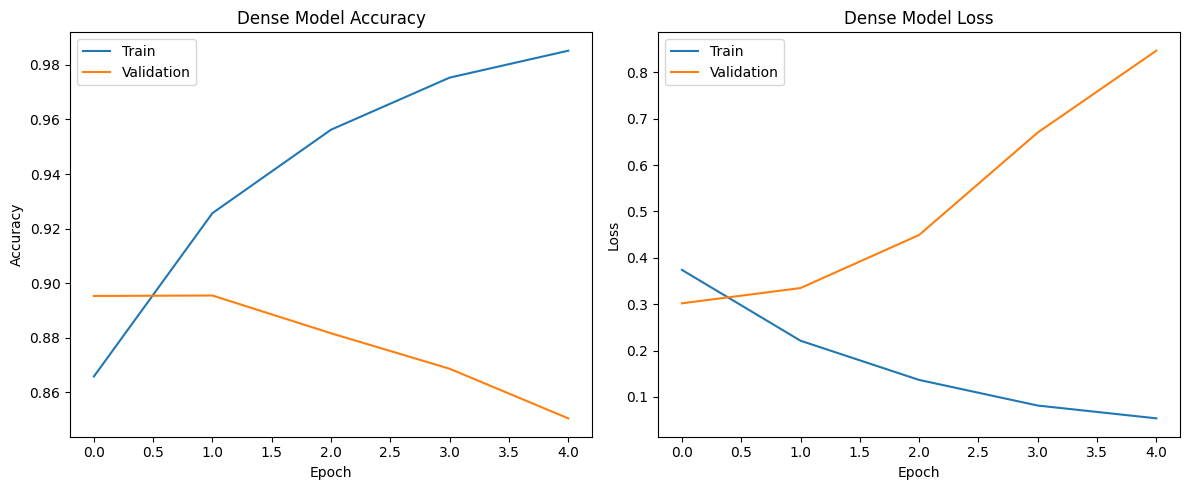

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dense.history['accuracy'])
plt.plot(history_dense.history['val_accuracy'])
plt.title('Dense Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history_dense.history['loss'])
plt.plot(history_dense.history['val_loss'])
plt.title('Dense Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.tight_layout()
plt.show()
